In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
df=pd.read_csv("ecommerce_dataset.csv")
df

,order_id,product,category,price,quantity,payment_method,date,total,Month,Discount,City Code,Order Priority Code,Latitude,Longtitude
0,1,Watch,Electronics,12652.30,4,Easypaisa,01/01/2023,50609.20,January,0.0,1.0,2.0,1.0,0.0
1,2,Bag,Fashion,20053.64,2,Credit Card,02/01/2023,40107.28,January,0.1,1.0,2.0,1.0,0.0
2,3,Shoes,Fashion,13274.17,2,JazzCash,03/01/2023,26548.34,January,0.1,1.0,2.0,1.0,0.0
3,4,Bag,Electronics,15332.08,1,COD,04/01/2023,15332.08,January,0.1,1.0,2.0,1.0,0.0
4,5,Bag,Accessories,23165.07,1,Debit Card,05/01/2023,23165.07,January,0.0,1.0,NaN,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,4,Bag,Electronics,15332.08,1,COD,04/01/2023,15332.08,January,0.1,1.0,2.0,1.0,0.0
502,18,Headphones,Electronics,14085.56,2,Debit Card,18/01/2023,28171.12,January,0.0,1.0,2.0,1.0,0.0
503,19,Laptop,Accessories,53657.14,4,Debit Card,19/01/2023,214628.56,January,0.1,1.0,2.0,1.0,0.0
504,20,Watch,Fashion,74385.39,4,Credit Card,20/01/2023,297541.56,January,0.0,1.0,2.0,1.0,0.0


In [3]:
df.info

<bound method DataFrame.info of      order_id     product     category     price  quantity payment_method  \
0           1       Watch  Electronics  12652.30         4      Easypaisa   
1           2         Bag      Fashion  20053.64         2    Credit Card   
2           3       Shoes      Fashion  13274.17         2       JazzCash   
3           4         Bag  Electronics  15332.08         1            COD   
4           5         Bag  Accessories  23165.07         1     Debit Card   
..        ...         ...          ...       ...       ...            ...   
501         4         Bag  Electronics  15332.08         1            COD   
502        18  Headphones  Electronics  14085.56         2     Debit Card   
503        19      Laptop  Accessories  53657.14         4     Debit Card   
504        20       Watch      Fashion  74385.39         4    Credit Card   
505        21         Bag  Electronics  44762.65         4            COD   

           date      total    Month  Discou

In [4]:
df=df.drop(["Latitude","Longtitude"],axis=1)

In [5]:
df.rename(columns={
    "City Code": "City",
    "Order Priority Code": "Order Priority"
}, inplace=True)

In [6]:
df.duplicated().sum()

6

In [7]:
df=df.drop_duplicates()

In [8]:
df.duplicated().sum()

0

In [9]:
df.isnull().sum()

order_id           0
product            0
category           0
price              0
quantity           0
payment_method     0
date               0
total              0
Month              0
Discount           0
City              15
Order Priority    19
dtype: int64

In [10]:
df["City"] = df["City"].fillna(df["City"].median())

df["Order Priority"] = df["Order Priority"].fillna(
    df["Order Priority"].median()
)

In [12]:
df1 = df["product"].value_counts().head(5)

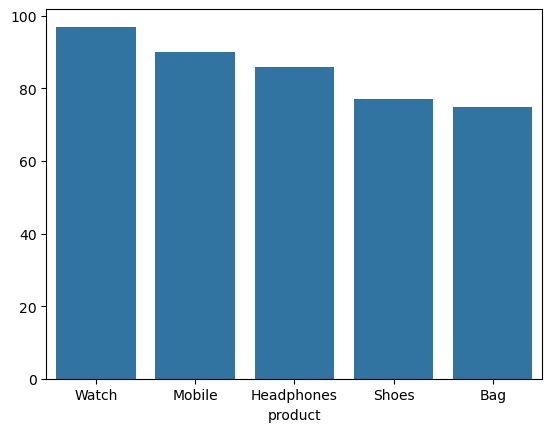

In [13]:
sns.barplot(x=df1.index, y=df1.values)
plt.show()

Observation: Top 5 selling products are watch,Mobile,Headphones,shoes,Bag

In [14]:
df2=df["payment_method"].value_counts()

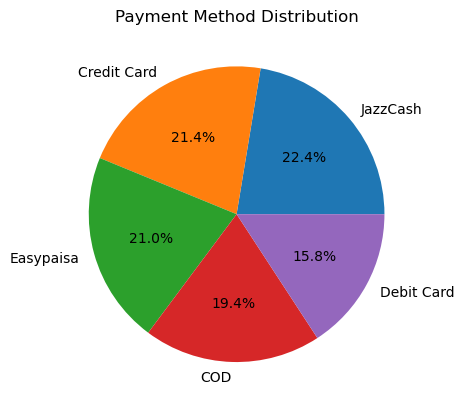

In [22]:
plt.pie(df2.values, labels=df2.index, autopct="%1.1f%%")
plt.title("Payment Method Distribution")
plt.show()

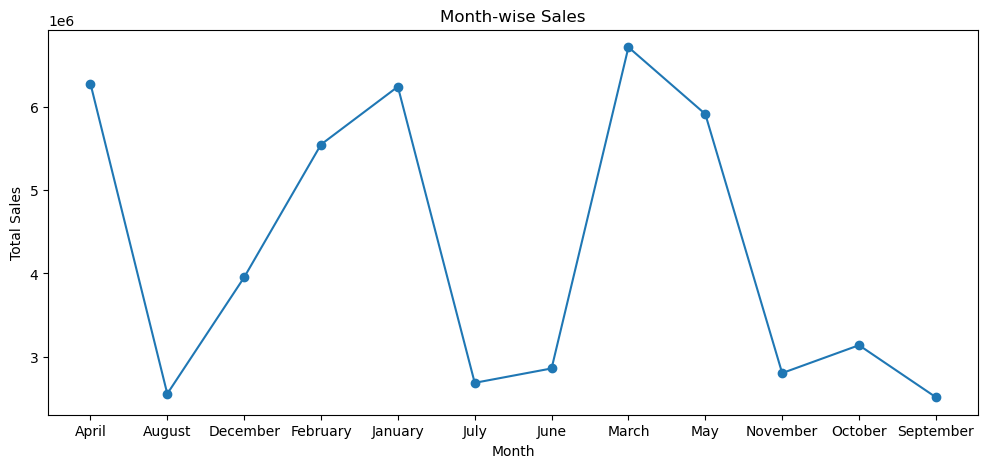

In [27]:
df3 = df.groupby("Month")["total"].sum()

plt.figure(figsize=(12, 5))
plt.plot(df3.index, df3.values, marker="o")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.title("Month-wise Sales")
plt.show()

In [28]:
city_names = {
    1: "Karachi",
    2: "Lahore",
    3: "Islamabad",
    4: "Faisalabad",
    5: "Quetta",
    6: "Peshawar"
}

df["City"] = df["City"].map(city_names)

In [29]:
df4 = df.groupby("City")["total"].sum()

Observation: highest sales are in karachi

In [37]:
df5 = df.groupby(["Month", "category"])["total"].sum().unstack()

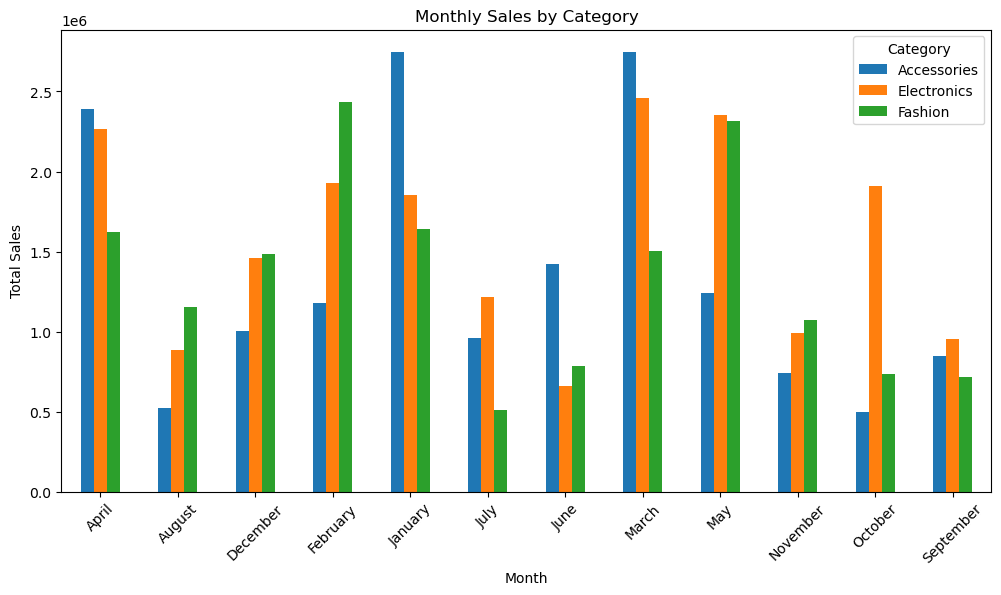

In [41]:
df5.plot(kind="bar", figsize=(12, 6))

plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.title("Monthly Sales by Category")
plt.xticks(rotation=45)
plt.legend(title="Category")
plt.show()

In [ ]:
Observation: 